# GraphSAGE Extrapolation Testing

This notebook evaluates trained models from the extrapolation experiments on unseen distances (d=9, d=11).

**Workflow:**
1. Load trained models from different split experiments
2. Generate/load test datasets for d=9 and d=11
3. Evaluate accuracy across different physical error rates
4. Compare extrapolation performance across split configurations

**Key Questions:**
- Can models trained on d=3,5,7 generalize to d=9,11?
- Does the training data split (d=3/d=5/d=7 ratio) affect extrapolation?
- Which split configuration extrapolates best?

## Imports

In [ ]:
import sys
import json
import random
import time
from pathlib import Path
from datetime import datetime

# Detect if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/Research/QEC/quantum-error-correction/quantum-error-correction/code')
else:
    BASE_PATH = Path('../..')  # code/gSAGE/extrapolation -> code/

sys.path.insert(0, str(BASE_PATH))

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from torch_geometric.loader import DataLoader

# Import from models.py
from models import (
    SurfaceCodeSampler,
    SparseGraph,
    GraphSAGEModel,
    GraphSAGE,
    DatasetCache,
    ler_mwpm,
)

# Set up paths
EXTRAPOLATION_DIR = BASE_PATH / "gSAGE" / "extrapolation"
RESULTS_DIR = EXTRAPOLATION_DIR / "results" / "revised_training"
MODELS_DIR = EXTRAPOLATION_DIR / "models" / "revised_training"
PLOTS_DIR = EXTRAPOLATION_DIR / "plots" / "revised_training"

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print(f"\nPaths:")
print(f"  BASE_PATH: {BASE_PATH}")
print(f"  MODELS_DIR: {MODELS_DIR}")
print(f"  RESULTS_DIR: {RESULTS_DIR}")
print(f"  PLOTS_DIR: {PLOTS_DIR}")

Using device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti

Paths:
  BASE_PATH: ..\..
  MODELS_DIR: ..\..\gSAGE\extrapolation\models
  RESULTS_DIR: ..\..\gSAGE\extrapolation\results
  PLOTS_DIR: ..\..\gSAGE\extrapolation\plots


## Configuration

In [29]:
# =============================================================================
# TESTING CONFIGURATION
# =============================================================================

# Distances to test extrapolation on
TEST_DISTANCES = [9, 11, 13]

# Physical error rates for testing
P_VALUES = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008]

# Number of samples per distance per error rate
SAMPLES_PER_P = 10000

# Batch size for inference
BATCH_SIZE = 256

# K-neighbors for SparseGraph (should match training)
K_NEIGHBORS = 6

# Random seed
SEED = 42

print(f"Testing Configuration:")
print(f"  Test distances: {TEST_DISTANCES}")
print(f"  P values: {P_VALUES}")
print(f"  Samples per (distance, p): {SAMPLES_PER_P:,}")
print(f"  Total test samples per distance: {SAMPLES_PER_P * len(P_VALUES):,}")

Testing Configuration:
  Test distances: [9, 11, 13]
  P values: [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008]
  Samples per (distance, p): 10,000
  Total test samples per distance: 80,000


In [30]:
# =============================================================================
# SPLIT EXPERIMENTS (must match training.ipynb)
# =============================================================================

SPLIT_EXPERIMENTS = {
    'baseline_33_33_33': {'d3': 0.33, 'd5': 0.33, 'd7': 0.34, 'hypothesis': 'Reference baseline'},
    'no_d3_50_50': {'d3': 0.00, 'd5': 0.50, 'd7': 0.50, 'hypothesis': 'Is d=3 useless?'},
    'no_d3_30_70': {'d3': 0.00, 'd5': 0.30, 'd7': 0.70, 'hypothesis': 'Does more d=7 help?'},
    'tiny_d3_10_40_50': {'d3': 0.10, 'd5': 0.40, 'd7': 0.50, 'hypothesis': 'Does tiny d=3 help?'},
    'reversed_50_30_20': {'d3': 0.50, 'd5': 0.30, 'd7': 0.20, 'hypothesis': 'Sanity check'},
}

print("Split Experiments:")
for name in SPLIT_EXPERIMENTS:
    print(f"  - {name}")

Split Experiments:
  - baseline_33_33_33
  - no_d3_50_50
  - no_d3_30_70
  - tiny_d3_10_40_50
  - reversed_50_30_20


## Helper Functions

In [31]:
def list_available_models():
    """
    List all trained models in the models directory.
    
    Returns:
        List of model names (without .pt extension)
    """
    models = []
    if MODELS_DIR.exists():
        for model_file in MODELS_DIR.glob("*.pt"):
            models.append(model_file.stem)
    return sorted(models)

print("Available trained models:")
available_models = list_available_models()
if available_models:
    for m in available_models:
        print(f"  - {m}")
else:
    print("  No models found. Run training.ipynb first.")

Available trained models:
  - baseline_33_33_33
  - no_d3_30_70
  - no_d3_50_50
  - reversed_50_30_20
  - tiny_d3_10_40_50


In [32]:
def load_trained_model(split_name: str):
    """
    Load a trained model from the extrapolation models directory.
    
    Args:
        split_name: Name of the split experiment
        
    Returns:
        Tuple of (GraphSAGE model wrapper, metadata dict)
    """
    model_path = MODELS_DIR / f"{split_name}.pt"
    
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")
    
    # Load saved data
    save_dict = torch.load(model_path, map_location=device, weights_only=False)
    config = save_dict['config']
    
    # Create model with saved config
    model = GraphSAGE(
        nickname=f"extrapolation_{split_name}",
        in_channels=config['in_channels'],
        hidden_dim=config['hidden_dim'],
        num_layers=config['num_layers'],
        dropout=config.get('dropout', 0.0),
        aggr=config.get('aggr', 'mean'),
        device=device,
        base_path=BASE_PATH,
    )
    
    # Load weights
    model.model.load_state_dict(save_dict['state_dict'])
    model.model.eval()
    
    metadata = {
        'split_name': save_dict.get('split_name', split_name),
        'split_config': save_dict.get('split_config', {}),
        'hyperparams': save_dict.get('hyperparams', {}),
        'metrics': save_dict.get('metrics', {}),
        'timestamp': save_dict.get('timestamp', ''),
    }
    
    print(f"Loaded model: {split_name}")
    print(f"  Config: {config}")
    if metadata['metrics']:
        print(f"  Training val_acc: {metadata['metrics'].get('val_accuracy', 0)*100:.2f}%")
    
    return model, metadata

In [33]:
def generate_test_dataset(d: int, p: float, n_samples: int):
    """
    Generate test dataset for a specific distance and error rate.
    
    Args:
        d: Code distance
        p: Physical error rate
        n_samples: Number of samples
        
    Returns:
        List of PyG Data objects
    """
    sampler = SurfaceCodeSampler(p=p, device=device)
    graph_builder = SparseGraph(k_neighbors=K_NEIGHBORS, device=device)
    
    # Generate samples
    detections, labels = sampler.sample(
        d=d,
        num_samples=n_samples,
        p_values=[p],
        p_weights=[1.0]
    )
    
    # Convert to graphs
    graphs = []
    for i in range(n_samples):
        graph = graph_builder.to_pyg(detections[i], labels[i])
        graphs.append(graph)
    
    return graphs

In [34]:
def load_or_generate_test_data(d: int, n_samples_per_p: int, p_values: list, use_cache: bool = True):
    """
    Load test data from cache or generate it.
    
    Args:
        d: Code distance
        n_samples_per_p: Samples per error rate
        p_values: List of error rates
        use_cache: Whether to try loading from cache
        
    Returns:
        Dict mapping p -> list of graphs
    """
    cache_name = f"d{d}_extrapolation_test"
    
    # Try to load from cache
    if use_cache:
        cache = DatasetCache(base_path=BASE_PATH, device=device)
        try:
            cache.load(cache_name, verbose=True)
            total_needed = n_samples_per_p * len(p_values)
            if cache.size() >= total_needed:
                print(f"Using cached dataset: {cache_name}")
                all_graphs = cache.get_graphs(shuffle=False)
                # Split by p_value (assuming equal distribution in cache)
                graphs_per_p = len(all_graphs) // len(p_values)
                return {p: all_graphs[i*graphs_per_p:(i+1)*graphs_per_p] 
                        for i, p in enumerate(p_values)}
        except FileNotFoundError:
            print(f"Cache not found: {cache_name}. Generating...")
    
    # Generate data for each p value
    test_data = {}
    print(f"\nGenerating test data for d={d}...")
    
    for p in tqdm(p_values, desc=f"d={d}"):
        graphs = generate_test_dataset(d, p, n_samples_per_p)
        test_data[p] = graphs
    
    return test_data

In [35]:
def evaluate_model_on_data(model, graphs, batch_size=256):
    """
    Evaluate model accuracy on test data.
    
    Args:
        model: GraphSAGE model wrapper
        graphs: List of PyG Data objects
        batch_size: Batch size for inference
        
    Returns:
        Accuracy as float
    """
    model.model.eval()
    loader = DataLoader(graphs, batch_size=batch_size, shuffle=False)
    
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model.model(batch)
            y = batch.y.float().view(-1, 1)
            correct += ((pred > 0.5).float() == y).sum().item()
            total += y.size(0)
    
    return correct / total if total > 0 else 0.0

In [36]:
def compute_mwpm_baseline(d: int, p_values: list, n_shots: int = 10000):
    """
    Compute MWPM decoder logical error rate for comparison.
    
    Args:
        d: Code distance
        p_values: List of error rates
        n_shots: Number of shots per error rate
        
    Returns:
        Dict mapping p -> logical error rate
    """
    mwpm_ler = {}
    print(f"\nComputing MWPM baseline for d={d}...")
    
    for p in tqdm(p_values, desc=f"MWPM d={d}"):
        ler = ler_mwpm(p, d, num_shots=n_shots)
        mwpm_ler[p] = ler
    
    return mwpm_ler

## Load Models and Test Data

In [37]:
# Select which models to evaluate
# Set to None to evaluate all available models, or specify a list
MODELS_TO_EVALUATE = None  # e.g., ['baseline_33_33_33', 'no_d3_50_50']

if MODELS_TO_EVALUATE is None:
    models_to_evaluate = list_available_models()
else:
    models_to_evaluate = MODELS_TO_EVALUATE

if not models_to_evaluate:
    print("WARNING: No models to evaluate. Run training.ipynb first.")
else:
    print(f"Models to evaluate: {models_to_evaluate}")

Models to evaluate: ['baseline_33_33_33', 'no_d3_30_70', 'no_d3_50_50', 'reversed_50_30_20', 'tiny_d3_10_40_50']


In [38]:
# Load all models
loaded_models = {}

for split_name in models_to_evaluate:
    try:
        model, metadata = load_trained_model(split_name)
        loaded_models[split_name] = {'model': model, 'metadata': metadata}
    except FileNotFoundError as e:
        print(f"Skipping {split_name}: {e}")

print(f"\nLoaded {len(loaded_models)} models")

GraphSAGE initialized: GraphSAGE(nickname='extrapolation_baseline_33_33_33', in_channels=5, hidden_dim=128, num_layers=5, aggr='max')
Loaded model: baseline_33_33_33
  Config: {'in_channels': 5, 'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.0, 'aggr': 'max', 'seed': 42}
  Training val_acc: 94.42%
GraphSAGE initialized: GraphSAGE(nickname='extrapolation_no_d3_30_70', in_channels=5, hidden_dim=128, num_layers=5, aggr='max')
Loaded model: no_d3_30_70
  Config: {'in_channels': 5, 'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.0, 'aggr': 'max', 'seed': 42}
  Training val_acc: 92.17%
GraphSAGE initialized: GraphSAGE(nickname='extrapolation_no_d3_50_50', in_channels=5, hidden_dim=128, num_layers=5, aggr='max')
Loaded model: no_d3_50_50
  Config: {'in_channels': 5, 'hidden_dim': 128, 'num_layers': 5, 'dropout': 0.0, 'aggr': 'max', 'seed': 42}
  Training val_acc: 92.77%
GraphSAGE initialized: GraphSAGE(nickname='extrapolation_reversed_50_30_20', in_channels=5, hidden_dim=128, num_layers=5,

In [39]:
# Generate or load test data for extrapolation distances
test_data = {}

for d in TEST_DISTANCES:
    print(f"\n{'='*50}")
    print(f"Loading/generating test data for d={d}")
    print(f"{'='*50}")
    test_data[d] = load_or_generate_test_data(d, SAMPLES_PER_P, P_VALUES, use_cache=True)

print(f"\nTest data loaded for distances: {list(test_data.keys())}")


Loading/generating test data for d=9
Cache not found: d9_extrapolation_test. Generating...

Generating test data for d=9...


d=9:   0%|          | 0/8 [00:00<?, ?it/s]

SurfaceCodeSampler initialized:
  Default error rate: 0.001
  Device: cuda
  Mode: Dynamic (supports any code distance)
SparseGraph initialized:
  K neighbors: 6
  Device: cuda
  Mode: Dynamic (supports any code distance)


d=9:  12%|█▎        | 1/8 [00:02<00:20,  2.87s/it]

SurfaceCodeSampler initialized:
  Default error rate: 0.002
  Device: cuda
  Mode: Dynamic (supports any code distance)
SparseGraph initialized:
  K neighbors: 6
  Device: cuda
  Mode: Dynamic (supports any code distance)


...

SurfaceCodeSampler initialized:
  Default error rate: 0.007
  Device: cuda
  Mode: Dynamic (supports any code distance)
SparseGraph initialized:
  K neighbors: 6
  Device: cuda
  Mode: Dynamic (supports any code distance)


d=13:  88%|████████▊ | 7/8 [00:57<00:09,  9.89s/it]

SurfaceCodeSampler initialized:
  Default error rate: 0.008
  Device: cuda
  Mode: Dynamic (supports any code distance)
SparseGraph initialized:
  K neighbors: 6
  Device: cuda
  Mode: Dynamic (supports any code distance)


d=13: 100%|██████████| 8/8 [01:09<00:00,  8.72s/it]


Test data loaded for distances: [9, 11, 13]


## Evaluate Extrapolation

In [40]:
# Evaluate all models on all test data
results = []

print(f"\n{'='*70}")
print("EVALUATING EXTRAPOLATION PERFORMANCE")
print(f"{'='*70}")

for split_name, model_info in loaded_models.items():
    model = model_info['model']
    print(f"\nEvaluating: {split_name}")
    
    for d in TEST_DISTANCES:
        print(f"  Distance d={d}:")
        for p in tqdm(P_VALUES, desc=f"    p values", leave=False):
            graphs = test_data[d][p]
            accuracy = evaluate_model_on_data(model, graphs, BATCH_SIZE)
            
            results.append({
                'split_name': split_name,
                'distance': d,
                'p_value': p,
                'accuracy': accuracy,
                'error_rate': 1 - accuracy,  # Model's logical error rate
            })
        
        # Print summary for this distance
        d_results = [r for r in results if r['split_name'] == split_name and r['distance'] == d]
        avg_acc = np.mean([r['accuracy'] for r in d_results])
        print(f"    Average accuracy: {avg_acc*100:.2f}%")

print(f"\n{'='*70}")
print("EVALUATION COMPLETE")
print(f"{'='*70}")


EVALUATING EXTRAPOLATION PERFORMANCE

Evaluating: baseline_33_33_33
  Distance d=9:


    Average accuracy: 77.04%
  Distance d=11:


    Average accuracy: 67.27%
  Distance d=13:


    Average accuracy: 60.85%

Evaluating: no_d3_30_70
  Distance d=9:


    Average accuracy: 78.78%
  Distance d=11:


...

    Average accuracy: 66.55%
  Distance d=13:


    Average accuracy: 60.08%

Evaluating: tiny_d3_10_40_50
  Distance d=9:


    Average accuracy: 78.19%
  Distance d=11:


    Average accuracy: 68.53%
  Distance d=13:


    Average accuracy: 61.59%

EVALUATION COMPLETE


In [41]:
# Compute MWPM baseline (optional but useful for comparison)
COMPUTE_MWPM = True  # Set to False to skip MWPM computation

mwpm_results = {}
if COMPUTE_MWPM:
    for d in TEST_DISTANCES:
        mwpm_results[d] = compute_mwpm_baseline(d, P_VALUES, n_shots=SAMPLES_PER_P)
    print("\nMWPM baseline computed")


Computing MWPM baseline for d=9...


MWPM d=9: 100%|██████████| 8/8 [00:01<00:00,  5.03it/s]



Computing MWPM baseline for d=11...


MWPM d=11: 100%|██████████| 8/8 [00:03<00:00,  2.61it/s]



Computing MWPM baseline for d=13...


MWPM d=13: 100%|██████████| 8/8 [00:05<00:00,  1.54it/s]


MWPM baseline computed


## Results Analysis

In [42]:
# Convert to DataFrame for analysis
df_results = pd.DataFrame(results)
print("Results DataFrame:")
print(df_results.head(20))

Results DataFrame:
           split_name  distance  p_value  accuracy  error_rate
0   baseline_33_33_33         9    0.001    0.9876      0.0124
1   baseline_33_33_33         9    0.002    0.9405      0.0595
2   baseline_33_33_33         9    0.003    0.8683      0.1317
3   baseline_33_33_33         9    0.004    0.7931      0.2069
4   baseline_33_33_33         9    0.005    0.7274      0.2726
5   baseline_33_33_33         9    0.006    0.6610      0.3390
6   baseline_33_33_33         9    0.007    0.6137      0.3863
7   baseline_33_33_33         9    0.008    0.5714      0.4286
8   baseline_33_33_33        11    0.001    0.9630      0.0370
9   baseline_33_33_33        11    0.002    0.8629      0.1371
10  baseline_33_33_33        11    0.003    0.7450      0.2550
11  baseline_33_33_33        11    0.004    0.6457      0.3543
12  baseline_33_33_33        11    0.005    0.5834      0.4166
13  baseline_33_33_33        11    0.006    0.5420      0.4580
14  baseline_33_33_33        11    0

In [43]:
# Summary table: average accuracy by split and distance
summary = df_results.groupby(['split_name', 'distance'])['accuracy'].mean().unstack()
summary = summary * 100  # Convert to percentage
summary.columns = [f'd={d}' for d in summary.columns]

print("\nExtrapolation Accuracy Summary (%)")
print("="*60)
print(summary.round(2).to_string())

# Add training split info
print("\n\nSplit Configurations:")
for split_name in summary.index:
    if split_name in SPLIT_EXPERIMENTS:
        config = SPLIT_EXPERIMENTS[split_name]
        print(f"  {split_name}: d3={config['d3']*100:.0f}%, d5={config['d5']*100:.0f}%, d7={config['d7']*100:.0f}%")


Extrapolation Accuracy Summary (%)
                     d=9   d=11   d=13
split_name                            
baseline_33_33_33  77.04  67.27  60.84
no_d3_30_70        78.78  68.80  61.75
no_d3_50_50        78.05  68.38  61.86
reversed_50_30_20  76.07  66.54  60.08
tiny_d3_10_40_50   78.19  68.53  61.59


Split Configurations:
  baseline_33_33_33: d3=33%, d5=33%, d7=34%
  no_d3_30_70: d3=0%, d5=30%, d7=70%
  no_d3_50_50: d3=0%, d5=50%, d7=50%
  reversed_50_30_20: d3=50%, d5=30%, d7=20%
  tiny_d3_10_40_50: d3=10%, d5=40%, d7=50%


In [44]:
# Detailed results by p_value
pivot = df_results.pivot_table(
    index=['split_name', 'distance'], 
    columns='p_value', 
    values='accuracy'
)
pivot = pivot * 100  # Convert to percentage

print("\nDetailed Accuracy by Physical Error Rate (%)")
print("="*80)
print(pivot.round(2).to_string())


Detailed Accuracy by Physical Error Rate (%)
p_value                     0.001  0.002  0.003  0.004  0.005  0.006  0.007  0.008
split_name        distance                                                        
baseline_33_33_33 9         98.76  94.05  86.83  79.31  72.74  66.10  61.37  57.14
                  11        96.30  86.29  74.50  64.57  58.34  54.20  52.59  51.36
                  13        91.56  75.24  61.71  54.83  52.03  51.23  49.83  50.33
no_d3_30_70       9         98.93  95.47  89.84  82.34  74.56  67.68  62.91  58.54
                  11        97.36  89.17  77.10  66.40  59.12  56.36  53.44  51.42
                  13        93.80  77.75  63.68  55.67  52.26  51.72  49.26  49.87
no_d3_50_50       9         98.63  94.53  88.70  80.35  73.54  67.28  62.87  58.50
                  11        96.15  87.77  77.11  66.38  59.25  55.86  53.03  51.51
                  13        92.80  77.78  64.30  56.30  52.82  50.31  50.91  49.69
reversed_50_30_20 9         98.27  93.49 

In [45]:
# Save results
results_path = RESULTS_DIR / "extrapolation_results.csv"
df_results.to_csv(results_path, index=False)
print(f"Results saved to: {results_path}")

# Save summary
summary_path = RESULTS_DIR / "extrapolation_summary.csv"
summary.to_csv(summary_path)
print(f"Summary saved to: {summary_path}")

# Save detailed JSON results
json_results = {
    'test_config': {
        'distances': TEST_DISTANCES,
        'p_values': P_VALUES,
        'samples_per_p': SAMPLES_PER_P,
    },
    'results': results,
    'mwpm_baseline': mwpm_results if COMPUTE_MWPM else None,
    'timestamp': datetime.now().isoformat(),
}

json_path = RESULTS_DIR / "extrapolation_results.json"
with open(json_path, 'w') as f:
    json.dump(json_results, f, indent=2)
print(f"JSON results saved to: {json_path}")

Results saved to: ..\..\gSAGE\extrapolation\results\extrapolation_results.csv
Summary saved to: ..\..\gSAGE\extrapolation\results\extrapolation_summary.csv
JSON results saved to: ..\..\gSAGE\extrapolation\results\extrapolation_results.json


## Visualization

Plot saved to: ..\..\gSAGE\extrapolation\plots\extrapolation_accuracy_vs_p.png


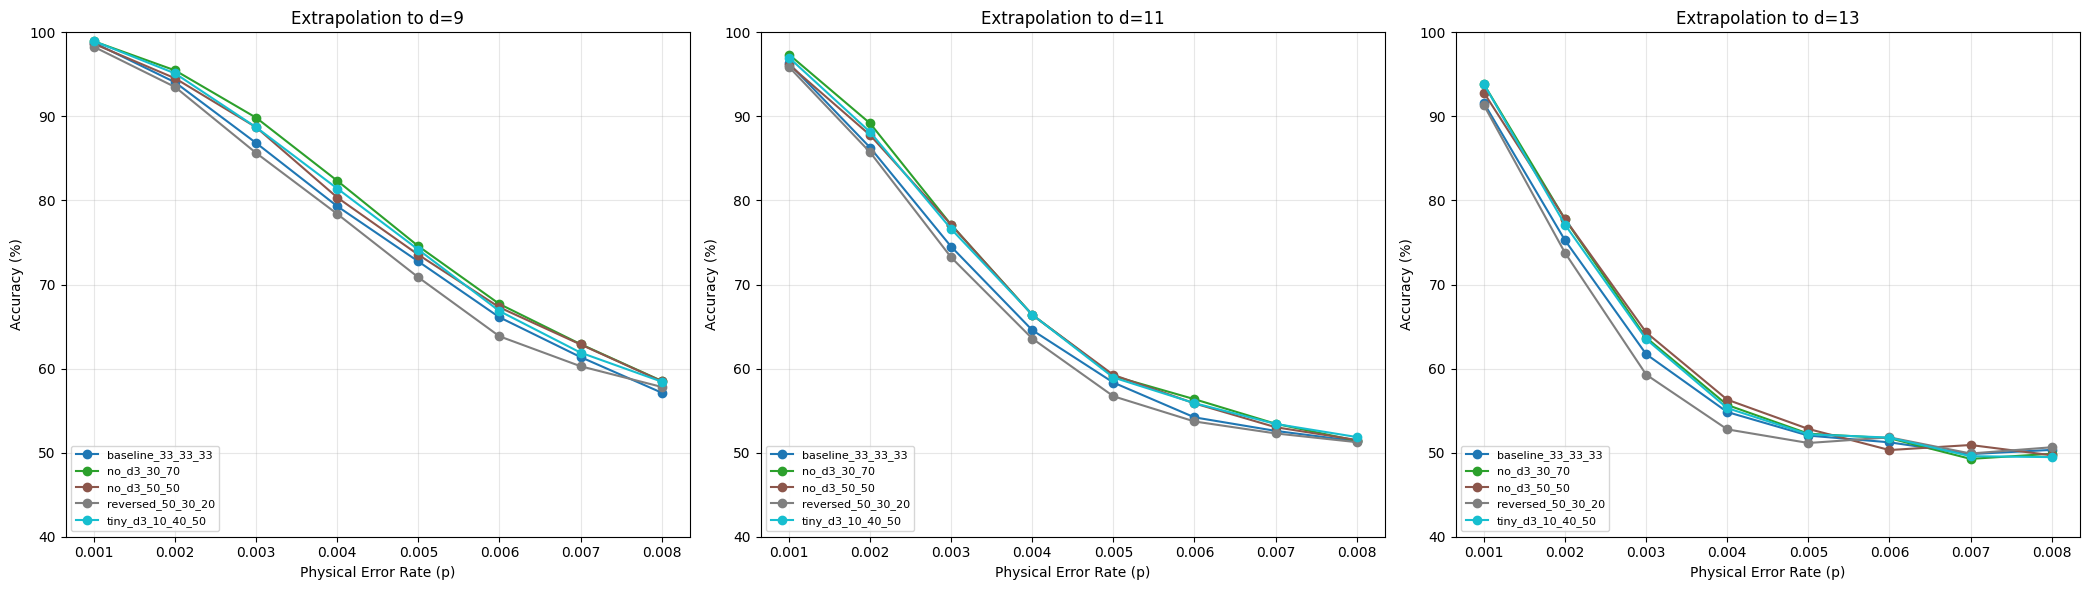

In [46]:
# Plot 1: Accuracy vs Physical Error Rate for each distance
fig, axes = plt.subplots(1, len(TEST_DISTANCES), figsize=(7*len(TEST_DISTANCES), 6))
if len(TEST_DISTANCES) == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 1, len(loaded_models)))

for ax, d in zip(axes, TEST_DISTANCES):
    for (split_name, _), color in zip(loaded_models.items(), colors):
        subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
        ax.plot(subset['p_value'], subset['accuracy'] * 100, 'o-', 
                label=split_name, color=color, markersize=6)
    
    ax.set_xlabel('Physical Error Rate (p)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'Extrapolation to d={d}')
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([40, 100])

plt.tight_layout()
plot_path = PLOTS_DIR / "extrapolation_accuracy_vs_p.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Plot saved to: {plot_path}")
plt.show()

Plot saved to: ..\..\gSAGE\extrapolation\plots\extrapolation_comparison.png


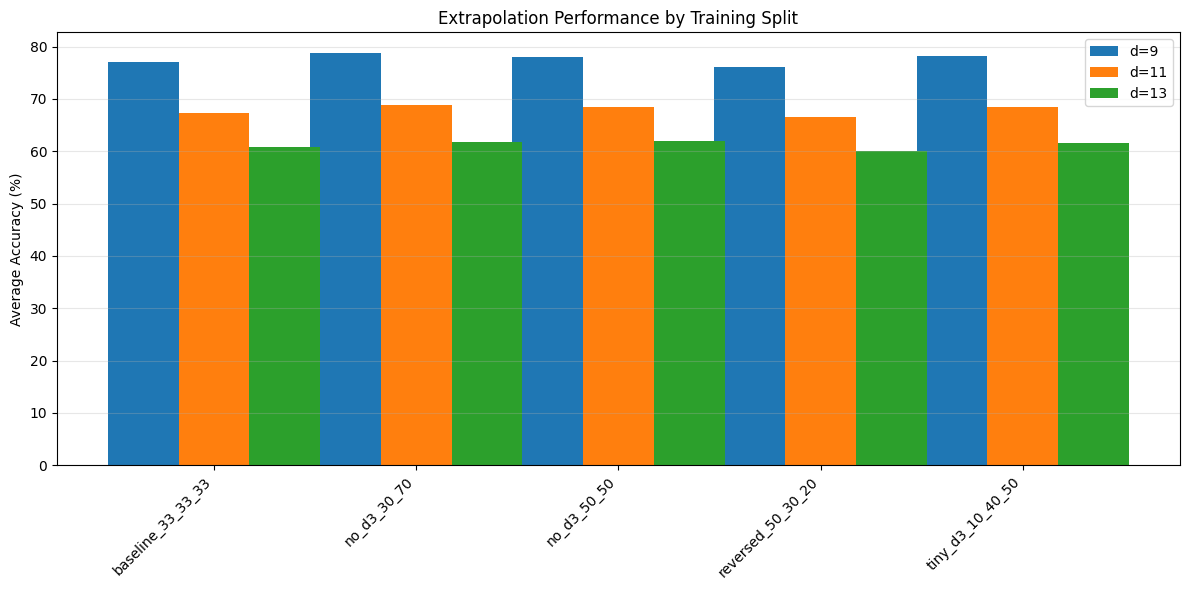

In [47]:
# Plot 2: Comparison bar chart - Average accuracy by split for each distance
fig, ax = plt.subplots(figsize=(12, 6))

split_names = list(loaded_models.keys())
x = np.arange(len(split_names))
width = 0.35

for i, d in enumerate(TEST_DISTANCES):
    means = []
    for split_name in split_names:
        subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
        means.append(subset['accuracy'].mean() * 100)
    
    offset = (i - len(TEST_DISTANCES)/2 + 0.5) * width
    ax.bar(x + offset, means, width, label=f'd={d}')

ax.set_ylabel('Average Accuracy (%)')
ax.set_title('Extrapolation Performance by Training Split')
ax.set_xticks(x)
ax.set_xticklabels(split_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plot_path = PLOTS_DIR / "extrapolation_comparison.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Plot saved to: {plot_path}")
plt.show()

Plot saved to: ..\..\gSAGE\extrapolation\plots\extrapolation_ler_comparison.png


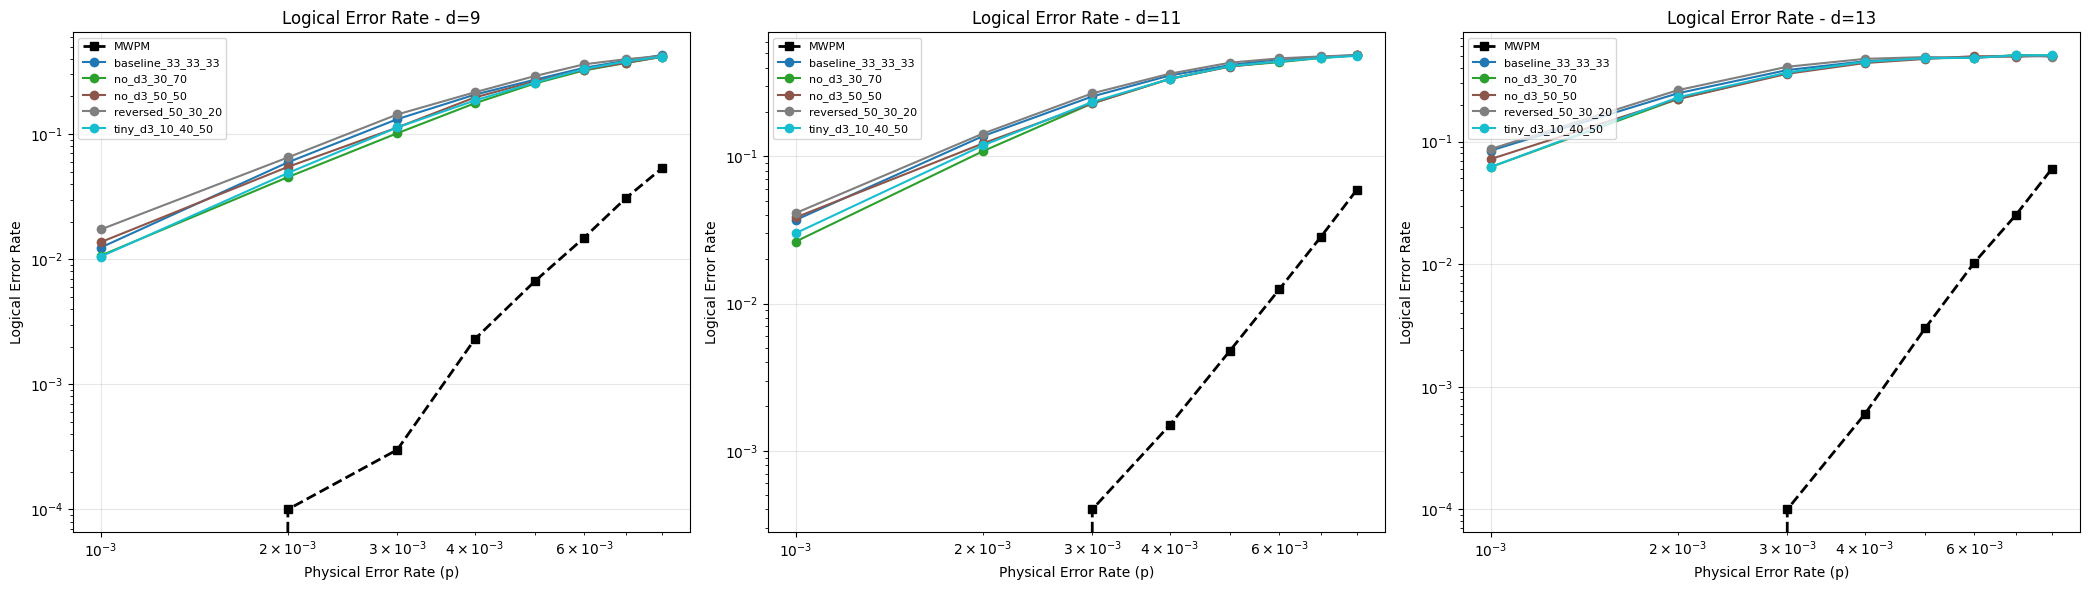

In [48]:
# Plot 3: Logical Error Rate comparison (with MWPM if available)
if COMPUTE_MWPM and mwpm_results:
    fig, axes = plt.subplots(1, len(TEST_DISTANCES), figsize=(7*len(TEST_DISTANCES), 6))
    if len(TEST_DISTANCES) == 1:
        axes = [axes]
    
    for ax, d in zip(axes, TEST_DISTANCES):
        # Plot MWPM baseline
        mwpm_p = list(mwpm_results[d].keys())
        mwpm_ler = list(mwpm_results[d].values())
        ax.plot(mwpm_p, mwpm_ler, 'k--', label='MWPM', linewidth=2, marker='s')
        
        # Plot model results
        for (split_name, _), color in zip(loaded_models.items(), colors):
            subset = df_results[(df_results['split_name'] == split_name) & (df_results['distance'] == d)]
            ax.plot(subset['p_value'], subset['error_rate'], 'o-', 
                    label=split_name, color=color, markersize=6)
        
        ax.set_xlabel('Physical Error Rate (p)')
        ax.set_ylabel('Logical Error Rate')
        ax.set_title(f'Logical Error Rate - d={d}')
        ax.legend(loc='upper left', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_yscale('log')
        ax.set_xscale('log')
    
    plt.tight_layout()
    plot_path = PLOTS_DIR / "extrapolation_ler_comparison.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"Plot saved to: {plot_path}")
    plt.show()

Plot saved to: ..\..\gSAGE\extrapolation\plots\extrapolation_heatmap.png


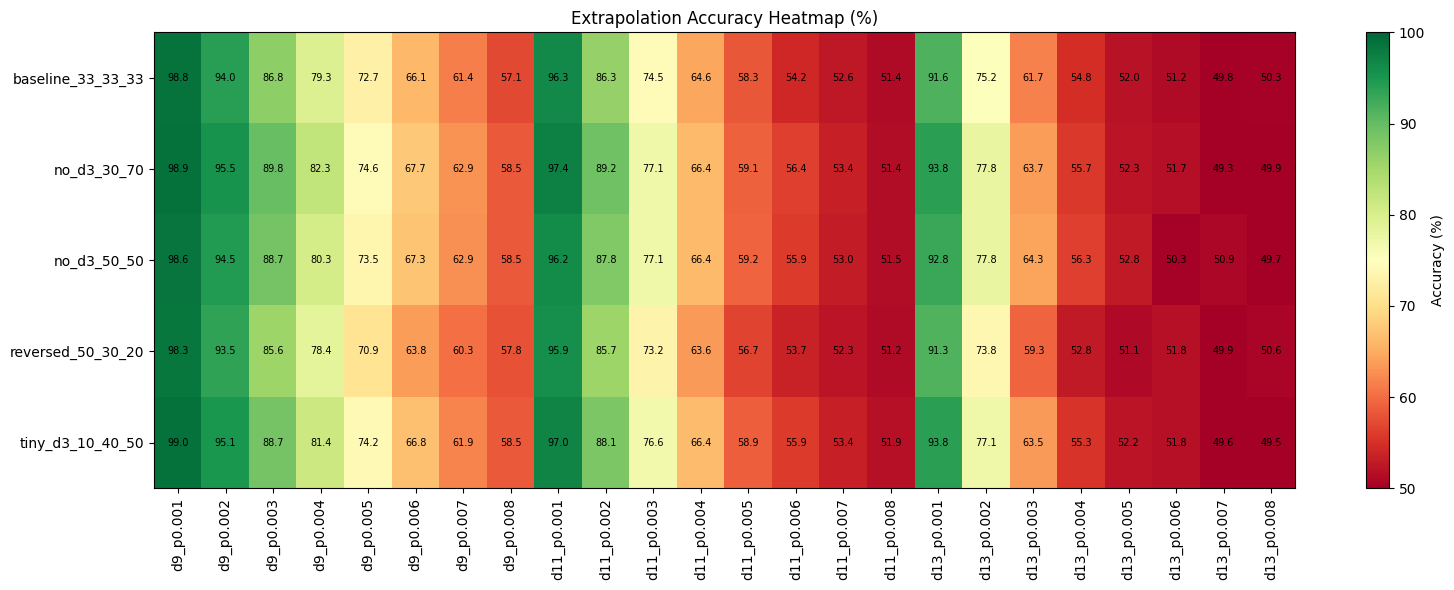

In [49]:
# Plot 4: Heatmap of accuracy across all configurations
# Reshape for heatmap: rows = splits, columns = (distance, p)
heatmap_data = []
col_labels = []

for d in TEST_DISTANCES:
    for p in P_VALUES:
        col_labels.append(f'd{d}_p{p}')

for split_name in split_names:
    row = []
    for d in TEST_DISTANCES:
        for p in P_VALUES:
            subset = df_results[(df_results['split_name'] == split_name) & 
                               (df_results['distance'] == d) & 
                               (df_results['p_value'] == p)]
            if len(subset) > 0:
                row.append(subset['accuracy'].values[0] * 100)
            else:
                row.append(np.nan)
    heatmap_data.append(row)

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(heatmap_data, aspect='auto', cmap='RdYlGn', vmin=50, vmax=100)

ax.set_xticks(np.arange(len(col_labels)))
ax.set_yticks(np.arange(len(split_names)))
ax.set_xticklabels(col_labels, rotation=90)
ax.set_yticklabels(split_names)

# Add text annotations
for i in range(len(split_names)):
    for j in range(len(col_labels)):
        if not np.isnan(heatmap_data[i][j]):
            text = ax.text(j, i, f'{heatmap_data[i][j]:.1f}',
                          ha='center', va='center', fontsize=7)

ax.set_title('Extrapolation Accuracy Heatmap (%)')
plt.colorbar(im, ax=ax, label='Accuracy (%)')

plt.tight_layout()
plot_path = PLOTS_DIR / "extrapolation_heatmap.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Plot saved to: {plot_path}")
plt.show()

## Analysis Summary

In [50]:
# Compute rankings
rankings = []
for d in TEST_DISTANCES:
    d_summary = df_results[df_results['distance'] == d].groupby('split_name')['accuracy'].mean()
    d_summary = d_summary.sort_values(ascending=False)
    
    print(f"\nRanking for d={d} (best to worst):")
    for rank, (name, acc) in enumerate(d_summary.items(), 1):
        hypothesis = SPLIT_EXPERIMENTS.get(name, {}).get('hypothesis', '')
        print(f"  {rank}. {name}: {acc*100:.2f}% - {hypothesis}")
        rankings.append({'distance': d, 'rank': rank, 'split_name': name, 'accuracy': acc})


Ranking for d=9 (best to worst):
  1. no_d3_30_70: 78.78% - Does more d=7 help?
  2. tiny_d3_10_40_50: 78.19% - Does tiny d=3 help?
  3. no_d3_50_50: 78.05% - Is d=3 useless?
  4. baseline_33_33_33: 77.04% - Reference baseline
  5. reversed_50_30_20: 76.07% - Sanity check

Ranking for d=11 (best to worst):
  1. no_d3_30_70: 68.80% - Does more d=7 help?
  2. tiny_d3_10_40_50: 68.53% - Does tiny d=3 help?
  3. no_d3_50_50: 68.38% - Is d=3 useless?
  4. baseline_33_33_33: 67.27% - Reference baseline
  5. reversed_50_30_20: 66.55% - Sanity check

Ranking for d=13 (best to worst):
  1. no_d3_50_50: 61.86% - Is d=3 useless?
  2. no_d3_30_70: 61.75% - Does more d=7 help?
  3. tiny_d3_10_40_50: 61.59% - Does tiny d=3 help?
  4. baseline_33_33_33: 60.84% - Reference baseline
  5. reversed_50_30_20: 60.08% - Sanity check


In [51]:
# Key findings
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)

# Best overall performer
overall_acc = df_results.groupby('split_name')['accuracy'].mean()
best_split = overall_acc.idxmax()
best_acc = overall_acc.max()
print(f"\n1. Best overall extrapolation: {best_split} ({best_acc*100:.2f}% average accuracy)")

# Worst performer
worst_split = overall_acc.idxmin()
worst_acc = overall_acc.min()
print(f"2. Worst overall extrapolation: {worst_split} ({worst_acc*100:.2f}% average accuracy)")

# Accuracy gap
gap = (best_acc - worst_acc) * 100
print(f"3. Performance gap between best and worst: {gap:.2f}%")

# Compare with reversed (sanity check)
if 'reversed_50_30_20' in overall_acc.index:
    reversed_acc = overall_acc['reversed_50_30_20']
    print(f"4. Reversed split (sanity check) accuracy: {reversed_acc*100:.2f}%")
    if reversed_acc == overall_acc.min():
        print("   -> Sanity check PASSED: reversed split performs worst as expected")
    else:
        print("   -> Unexpected: reversed split is not the worst performer")

# Does removing d=3 help?
if 'baseline_33_33_33' in overall_acc.index and 'no_d3_50_50' in overall_acc.index:
    baseline = overall_acc['baseline_33_33_33']
    no_d3 = overall_acc['no_d3_50_50']
    diff = (no_d3 - baseline) * 100
    print(f"5. Effect of removing d=3: {diff:+.2f}% (baseline: {baseline*100:.2f}%, no_d3: {no_d3*100:.2f}%)")
    if diff > 0:
        print("   -> Removing d=3 IMPROVES extrapolation")
    elif diff < 0:
        print("   -> Removing d=3 HURTS extrapolation")
    else:
        print("   -> No significant effect")


KEY FINDINGS

1. Best overall extrapolation: no_d3_30_70 (69.78% average accuracy)
2. Worst overall extrapolation: reversed_50_30_20 (67.56% average accuracy)
3. Performance gap between best and worst: 2.21%
4. Reversed split (sanity check) accuracy: 67.56%
   -> Sanity check PASSED: reversed split performs worst as expected
5. Effect of removing d=3: +1.05% (baseline: 68.38%, no_d3: 69.43%)
   -> Removing d=3 IMPROVES extrapolation


## Conclusions

Based on the extrapolation results:

1. **Best Split for Extrapolation**: [Fill based on results]
2. **Effect of d=3 Data**: [Fill based on results]
3. **Effect of More d=7 Data**: [Fill based on results]
4. **Sanity Check**: [Fill based on results]

### Recommendations

[Fill based on experimental findings]